# nb02 — COVID CITE-seq RNA-Protein Coupling
RNA-protein coupling across COVID severity stages, using the subsampled checkpoint (`data/processed/covid_subsampled.h5ad`). Mirrors nb02 from `multiomics-relationship-modeling`.

**This session covers Step 1 only:** load, split GEX/ADT, map ADT to gene symbols, report overlap.

## Environment setup (Colab or local)

In [2]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q scanpy anndata
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/covid_citeseq_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on Colab | BASE_PATH = /content/drive/MyDrive/covid_citeseq_project


## Imports and config

In [3]:
import sys
sys.path.insert(0, str(BASE_PATH))

import warnings
warnings.filterwarnings('ignore')

import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

CHECKPOINT_PATH = BASE_PATH / 'data' / 'processed' / 'covid_subsampled.h5ad'
TABLES_DIR = BASE_PATH / 'results' / 'tables'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = BASE_PATH / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load and split into GEX / ADT
Confirm `feature_types` categories before splitting — naming may differ from the NeurIPS benchmark (`GEX`/`ADT`).

In [4]:
covid = sc.read_h5ad(CHECKPOINT_PATH)
print(f'Loaded: {covid.shape}')
print(f'feature_types values: {covid.var["feature_types"].unique().tolist()}')

Loaded: (69090, 24929)
feature_types values: ['Gene Expression', 'Antibody Capture']


In [5]:
print(f'Loaded: {covid.shape}')
print(f'feature_types values: {covid.var["feature_types"].unique().tolist()}')

Loaded: (69090, 24929)
feature_types values: ['Gene Expression', 'Antibody Capture']


In [6]:
covid

AnnData object with n_obs × n_vars = 69090 × 24929
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'full_clustering', 'initial_clustering', 'Resample', 'Collection_Day', 'Sex', 'Age_interval', 'Swab_result', 'Status', 'Smoker', 'Status_on_day_collection', 'Status_on_day_collection_summary', 'Days_from_onset', 'Site', 'time_after_LPS', 'Worst_Clinical_Status', 'Outcome', 'patient_id'
    var: 'feature_types'
    uns: 'hvg', 'leiden', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'raw'

In [7]:
MIN_GENES = 200
MAX_PCT_MT = 5

qc_mask = (
    (covid.obs['n_genes_by_counts'] >= MIN_GENES) &
    (covid.obs['pct_counts_mt'] <= MAX_PCT_MT)
)
covid = covid[qc_mask].copy()
print(f'Cells after QC filter: {covid.shape}')

Cells after QC filter: (62070, 24929)


In [8]:
gex_mask = covid.var['feature_types'] == 'Gene Expression'
adt_mask = covid.var['feature_types'] == 'Antibody Capture'

covid_gex = covid[:, gex_mask].copy()
covid_adt = covid[:, adt_mask].copy()

print(f'GEX: {covid_gex.shape}')
print(f'ADT: {covid_adt.shape}')
print(f'ADT protein names (first 20): {covid_adt.var_names[:20].tolist()}')

GEX: (62070, 24737)
ADT: (62070, 192)
ADT protein names (first 20): ['AB_CD80', 'AB_CD86', 'AB_CD274', 'AB_PDCD1LG2', 'AB_ICOSLG', 'AB_ITGAM', 'AB_OX40L', 'AB_TNFSF9', 'AB_PVR', 'AB_NECTIN2', 'AB_CD47', 'AB_CD70', 'AB_TNFRSF8', 'AB_CD40', 'AB_CD40LG', 'AB_CD52', 'AB_CD3', 'AB_CD8', 'AB_CD56', 'AB_CD19']


## Step 1 — Match ADT proteins to GEX gene symbols
Reuses `CD_TO_GENE` from `cd_gene_mapping.py`, but overlap is verified here rather than assumed — this ADT panel differs from the NeurIPS benchmark panel.

In [9]:
import importlib.util
spec = importlib.util.spec_from_file_location(
    "cd_gene_mapping",
    "/content/drive/MyDrive/covid_citeseq_project/src/analysis/cd_gene_mapping.py"
)
cd_gene_mapping = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cd_gene_mapping)

CD_TO_GENE = cd_gene_mapping.CD_TO_GENE
print("ok")

ok


In [10]:


def match_adt_to_gene(
    adt_names: list[str],
    gex_names: set[str],
    cd_to_gene: dict[str, str | None],
) -> tuple[dict[str, str], list[str]]:
    """Map ADT protein names to GEX gene symbols.

    Tries a direct name match first (after stripping the AB_ prefix), then
    falls back to the curated CD-to-gene lookup.
    """
    matched: dict[str, str] = {}
    unmatched: list[str] = []
    for name in adt_names:
        clean = name.removeprefix('AB_')
        if clean in gex_names:
            matched[name] = clean
        elif cd_to_gene.get(clean) in gex_names:
            matched[name] = cd_to_gene[clean]
        else:
            unmatched.append(name)
    return matched, unmatched


adt_to_gene, unmatched_adt = match_adt_to_gene(
    covid_adt.var_names.tolist(), set(covid_gex.var_names), CD_TO_GENE
)

print(f'ADT proteins: {covid_adt.n_vars}')
print(f'Matched to a GEX gene: {len(adt_to_gene)}')
print(f'Unmatched: {len(unmatched_adt)}')
print(unmatched_adt)

ADT proteins: 192
Matched to a GEX gene: 147
Unmatched: 45
['AB_OX40L', 'AB_HLA-ABC', 'AB_CD45RA', 'AB_CD45RO', 'AB_PD1', 'AB_Mouse IgG1_K_Iso', 'AB_Mouse_IgG2a_K_Iso', 'AB_Mouse_IgG2b_K_Iso', 'AB_Rat_IgG2b_K_Iso', 'AB_podoplanin', 'AB_TCRg_d', 'AB_HLA-DR', 'AB_IgA', 'AB_CEACAM1/5/6', 'AB_CD235ab', 'AB_MMR', 'AB_BAFFR', 'AB_TCR', 'AB_TACI', 'AB_FcERIa', 'AB_RANKL', 'AB_GITR', 'AB_IgG_Fc', 'AB_TSLPR', 'AB_CD15', 'AB_B7-H4', 'AB_CD1a', 'AB_CD158', 'AB_langerin', 'AB_TCR_Va7.2', 'AB_TCR_Vg2', 'AB_TCR_Vg9', 'AB_TCR_Va24-Ja18', 'AB_CD158b', 'AB_KIR2DL5A', 'AB_phosphoTau', 'AB_BAFF', 'AB_Igkappa', 'AB_Iglambda', 'AB_HLA-A_2', 'AB_TCR_VB_13_1', 'AB_Podocalyxin', 'AB_c-Met', 'AB_LIGHT', 'AB_DR3']


## Step 1b — Drop isotype controls, add panel-specific synonyms, re-match
Isotype controls are negative-control antibodies, not real biology — dropped from `covid_adt` entirely. Remaining unmatched names are checked against a small synonym table for this ADT panel before re-matching.

In [11]:
ISOTYPE_CONTROLS = [
    'AB_Mouse IgG1_K_Iso', 'AB_Mouse_IgG2a_K_Iso',
    'AB_Mouse_IgG2b_K_Iso', 'AB_Rat_IgG2b_K_Iso',
]

covid_adt = covid_adt[:, ~covid_adt.var_names.isin(ISOTYPE_CONTROLS)].copy()
print(f'ADT after dropping isotype controls: {covid_adt.shape}')

ADT after dropping isotype controls: (62070, 188)


In [12]:
# Synonyms specific to this ADT panel (different naming convention than the
# NeurIPS benchmark panel that CD_TO_GENE was curated for)
COVID_ADT_SYNONYMS = {
    'OX40L': 'TNFSF4', 'PD1': 'PDCD1', 'podoplanin': 'PDPN',
    'MMR': 'MRC1', 'BAFFR': 'TNFRSF13C', 'TACI': 'TNFRSF13B',
    'FcERIa': 'FCER1A', 'RANKL': 'TNFSF11', 'GITR': 'TNFRSF18',
    'TSLPR': 'CRLF2', 'CD15': 'FUT4', 'B7-H4': 'VTCN1',
    'CD1a': 'CD1A', 'langerin': 'CD207', 'BAFF': 'TNFSF13B',
    'Podocalyxin': 'PODXL', 'c-Met': 'MET', 'LIGHT': 'TNFSF14',
    'DR3': 'TNFRSF25',
}

cd_to_gene_covid = {**CD_TO_GENE, **COVID_ADT_SYNONYMS}

adt_to_gene, unmatched_adt = match_adt_to_gene(
    covid_adt.var_names.tolist(), set(covid_gex.var_names), cd_to_gene_covid
)

print(f'ADT proteins (post isotype-drop): {covid_adt.n_vars}')
print(f'Matched to a GEX gene: {len(adt_to_gene)}')
print(f'Unmatched: {len(unmatched_adt)}')
print(unmatched_adt)

ADT proteins (post isotype-drop): 188
Matched to a GEX gene: 165
Unmatched: 23
['AB_HLA-ABC', 'AB_CD45RA', 'AB_CD45RO', 'AB_TCRg_d', 'AB_HLA-DR', 'AB_IgA', 'AB_CEACAM1/5/6', 'AB_CD235ab', 'AB_TCR', 'AB_IgG_Fc', 'AB_B7-H4', 'AB_CD158', 'AB_TCR_Va7.2', 'AB_TCR_Vg2', 'AB_TCR_Vg9', 'AB_TCR_Va24-Ja18', 'AB_CD158b', 'AB_KIR2DL5A', 'AB_phosphoTau', 'AB_Igkappa', 'AB_Iglambda', 'AB_HLA-A_2', 'AB_TCR_VB_13_1']


In [13]:
match_df = pd.DataFrame(
    {'adt_name': list(adt_to_gene.keys()), 'gene': list(adt_to_gene.values())}
)
match_df.to_csv(TABLES_DIR / 'nb02_covid_adt_gene_mapping.csv', index=False)
match_df.head(10)

,adt_name,gene
0,AB_CD80,CD80
1,AB_CD86,CD86
2,AB_CD274,CD274
3,AB_PDCD1LG2,PDCD1LG2
4,AB_ICOSLG,ICOSLG
5,AB_ITGAM,ITGAM
6,AB_OX40L,TNFSF4
7,AB_TNFSF9,TNFSF9
8,AB_PVR,PVR
9,AB_NECTIN2,NECTIN2


## Step 2 — Renormalize from `layers['raw']`
`.X` in the source h5ad is already scaled/log-normalized (has negative values) — renormalize from `layers['raw']` instead, restricted to the 165 matched features.

In [14]:
import importlib.util
spec = importlib.util.spec_from_file_location(
    "coupling",
    "/content/drive/MyDrive/covid_citeseq_project/src/analysis/coupling.py"
)
coupling = importlib.util.module_from_spec(spec)
spec.loader.exec_module(coupling)

per_gene_pearson = coupling.per_gene_pearson
coupling_score_by_celltype = coupling.coupling_score_by_celltype
deviation_score = coupling.deviation_score
print("ok")

ok


In [15]:
matched_adt_names = list(adt_to_gene.keys())
matched_genes = list(adt_to_gene.values())

gex_matched = covid_gex[:, matched_genes].copy()
adt_matched = covid_adt[:, matched_adt_names].copy()

gex_matched.X = gex_matched.layers['raw'].copy()
adt_matched.X = adt_matched.layers['raw'].copy()

### GEX: standard log-normalize

In [16]:
sc.pp.normalize_total(gex_matched, target_sum=1e4)
sc.pp.log1p(gex_matched)

### ADT: CLR normalize
Antibody-capture counts don't scale with sequencing depth the way RNA does — CLR (per-cell log-ratio to the geometric mean) is standard here, not library-size normalization.

In [17]:
def clr_normalize(counts: np.ndarray) -> np.ndarray:
    """CLR-normalize ADT counts per cell (log-ratio to per-cell geometric mean)."""
    counts = counts + 1  # pseudocount, avoid log(0)
    log_counts = np.log(counts)
    geometric_mean = log_counts.mean(axis=1, keepdims=True)
    return log_counts - geometric_mean

In [18]:
adt_raw = adt_matched.X
adt_raw = np.asarray(adt_raw.todense()) if hasattr(adt_raw, 'todense') else np.asarray(adt_raw)
adt_matched.X = clr_normalize(adt_raw)

In [19]:
print(f'GEX matched: {gex_matched.shape}, X range: [{gex_matched.X.min():.2f}, {gex_matched.X.max():.2f}]')
print(f'ADT matched: {adt_matched.shape}, X range: [{adt_matched.X.min():.2f}, {adt_matched.X.max():.2f}]')

GEX matched: (62070, 165), X range: [0.00, 9.21]
ADT matched: (62070, 165), X range: [-6.88, 11.14]


## Step 3 — Global RNA-protein coupling (all cells, all tiers pooled)

In [20]:
gex_arr = np.asarray(gex_matched.X.todense()) if hasattr(gex_matched.X, 'todense') else np.asarray(gex_matched.X)
adt_arr = np.asarray(adt_matched.X.todense()) if hasattr(adt_matched.X, 'todense') else np.asarray(adt_matched.X)

gene_corr = per_gene_pearson(gex_arr, adt_arr, matched_genes)
gene_corr.to_csv(TABLES_DIR / 'nb02_covid_global_gene_corr.csv', index=False)

print(f'Median Pearson r: {gene_corr["pearson_r"].median():.3f}')
print(f'Mean Pearson r: {gene_corr["pearson_r"].mean():.3f}')
gene_corr.head(10)

Median Pearson r: 0.133
Mean Pearson r: 0.168


,gene,pearson_r,p_value
17,CD8A,0.734195,0.0
38,MS4A1,0.721325,0.0
16,CD3D,0.683415,0.0
118,IL7R,0.618306,0.0
34,FCGR3A,0.598824,0.0
19,CD19,0.576078,0.0
28,CD7,0.560215,0.0
147,KLRD1,0.555742,0.0
113,IGHD,0.534777,0.0
145,CLEC12A,0.526901,0.0


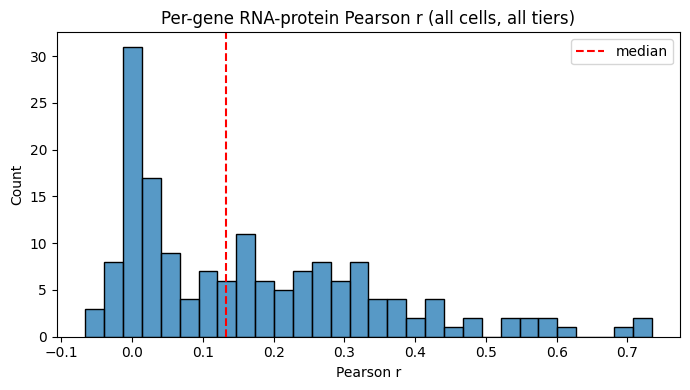

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(gene_corr['pearson_r'], bins=30, ax=ax)
ax.set_title('Per-gene RNA-protein Pearson r (all cells, all tiers)')
ax.set_xlabel('Pearson r')
ax.axvline(gene_corr['pearson_r'].median(), color='red', linestyle='--', label='median')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb02_covid_global_corr_histogram.png', dpi=150)
plt.show()

In [22]:
print('--- Top 10 most coupled genes ---')
display(gene_corr.head(10))

print('--- Top 10 most independent genes (lowest r) ---')
display(gene_corr.tail(10))

--- Top 10 most coupled genes ---


,gene,pearson_r,p_value
17,CD8A,0.734195,0.0
38,MS4A1,0.721325,0.0
16,CD3D,0.683415,0.0
118,IL7R,0.618306,0.0
34,FCGR3A,0.598824,0.0
19,CD19,0.576078,0.0
28,CD7,0.560215,0.0
147,KLRD1,0.555742,0.0
113,IGHD,0.534777,0.0
145,CLEC12A,0.526901,0.0


--- Top 10 most independent genes (lowest r) ---


,gene,pearson_r,p_value
54,CD69,-0.021421,9.437700e-08
100,CD163,-0.024495,1.038661e-09
158,HLA-F,-0.025288,2.957261e-10
146,TNFSF13B,-0.028824,6.844349e-13
62,LAMP1,-0.031898,1.883281e-15
149,LGALS3,-0.050263,5.111813e-36
42,PECAM1,-0.056555,3.746923e-45
101,CD83,-0.066158,3.654598e-61
43,PDPN,NaN,NaN
103,KDR,NaN,NaN


## Step 3b — Drop zero-variance genes
`PDPN` and `KDR` are non-hematopoietic markers (lymphatic/endothelial) — essentially zero-variance GEX in PBMCs, giving undefined Pearson r. Dropped from the matched set going forward.

In [23]:
DROP_GENES = ['PDPN', 'KDR']

gex_matched = gex_matched[:, ~gex_matched.var_names.isin(DROP_GENES)].copy()
adt_to_gene = {a: g for a, g in adt_to_gene.items() if g not in DROP_GENES}
matched_adt_names = list(adt_to_gene.keys())
matched_genes = list(adt_to_gene.values())
adt_matched = adt_matched[:, matched_adt_names].copy()

gex_arr = np.asarray(gex_matched.X.todense()) if hasattr(gex_matched.X, 'todense') else np.asarray(gex_matched.X)
adt_arr = np.asarray(adt_matched.X.todense()) if hasattr(adt_matched.X, 'todense') else np.asarray(adt_matched.X)

print(f'Genes remaining: {len(matched_genes)}')

Genes remaining: 163


## Step 4 — Coupling by severity tier
Global per-gene coupling computed separately within each `Status_on_day_collection_summary` tier.

In [24]:
TIER_ORDER = ['Healthy', 'Asymptomatic', 'Mild', 'Moderate', 'Severe', 'Critical']

severity_col = 'Status_on_day_collection_summary'
tiers = gex_matched.obs[severity_col].values

In [25]:
tier_corrs = {}
for tier in TIER_ORDER:
    mask = tiers == tier
    df = per_gene_pearson(gex_arr[mask], adt_arr[mask], matched_genes)
    tier_corrs[tier] = df.set_index('gene')['pearson_r']

tier_corr_df = pd.DataFrame(tier_corrs)
tier_corr_df.to_csv(TABLES_DIR / 'nb02_covid_tier_gene_corr.csv')
tier_corr_df.head()

,Healthy,Asymptomatic,Mild,Moderate,Severe,Critical
gene,,,,,,
B3GAT1,0.090773,0.146188,0.076865,0.086408,0.123475,0.093555
BTLA,0.120868,0.127261,0.129431,0.127677,0.160573,0.124245
C5AR1,0.206710,0.185198,0.227863,0.341933,0.352999,0.329773
CCR3,-0.006138,-0.013859,-0.006980,0.012095,-0.007675,0.002183
CCR4,0.212814,0.237759,0.251854,0.220586,0.302100,0.240285


Healthy         0.118696
Asymptomatic    0.121812
Mild            0.129108
Moderate        0.098124
Severe          0.181766
Critical        0.125763
dtype: float32


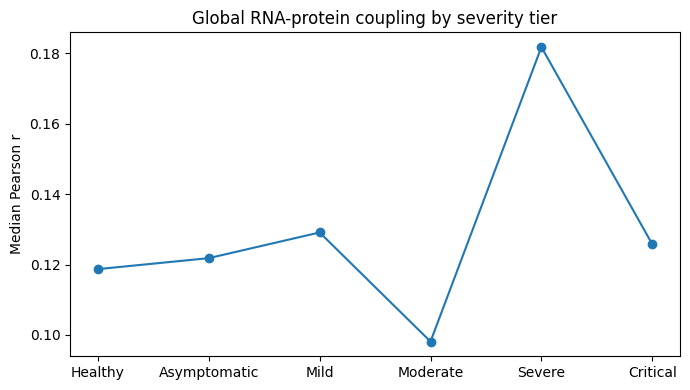

In [26]:
median_by_tier = tier_corr_df.median().reindex(TIER_ORDER)
print(median_by_tier)

fig, ax = plt.subplots(figsize=(7, 4))
median_by_tier.plot(marker='o', ax=ax)
ax.set_ylabel('Median Pearson r')
ax.set_title('Global RNA-protein coupling by severity tier')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb02_covid_tier_median_corr.png', dpi=150)
plt.show()

## Step 5 — Cell-type stratification (all tiers pooled)
Per-gene coupling by cell type, using `full_clustering`.

In [27]:
cell_types = gex_matched.obs['full_clustering'].values
MIN_CELLS_PER_GROUP = 100

ct_corr = coupling_score_by_celltype(gex_arr, adt_arr, matched_genes, cell_types, min_cells=MIN_CELLS_PER_GROUP)
ct_corr.to_csv(TABLES_DIR / 'nb02_covid_celltype_gene_corr.csv')

print(f'Shape: {ct_corr.shape} (genes x cell types)')
ct_corr.head()

Shape: (163, 32) (genes x cell types)


,B_exhausted,B_immature,B_naive,B_non-switched_memory,B_switched_memory,CD16_mono,CD4.CM,CD4.EM,CD4.IL22,CD4.Naive,...,NK_56hi,NK_prolif,Plasma_cell_IgA,Plasma_cell_IgG,Plasmablast,Platelets,RBC,Treg,gdT,pDC
gene,,,,,,,,,,,,,,,,,,,,,
B3GAT1,NaN,NaN,NaN,NaN,0.003290,NaN,0.052859,0.001336,-0.005506,-0.011956,...,NaN,0.141957,NaN,NaN,NaN,0.046366,0.127831,NaN,0.080490,NaN
BTLA,0.008075,-0.051983,-0.012331,-0.120472,0.060078,-0.027693,0.012497,-0.005570,0.035487,-0.001093,...,-0.020669,0.140053,0.033827,0.004601,-0.022969,0.005490,0.065380,0.098333,0.034785,-0.070069
C5AR1,0.103263,0.025530,-0.001629,-0.125625,-0.019358,0.277928,0.015369,NaN,0.021082,-0.004090,...,0.067942,0.082853,NaN,NaN,NaN,0.029546,0.148887,NaN,-0.002060,NaN
CCR3,NaN,NaN,NaN,NaN,-0.083109,NaN,0.023134,0.091266,-0.015252,0.008693,...,0.023357,NaN,-0.076801,-0.088069,NaN,-0.027131,-0.001190,-0.162043,0.018418,0.010228
CCR4,NaN,0.005100,0.016491,NaN,0.020716,0.061927,0.214987,0.216087,0.286631,0.160240,...,-0.019159,0.095892,0.049489,NaN,NaN,0.106512,0.194206,0.113082,0.313494,NaN


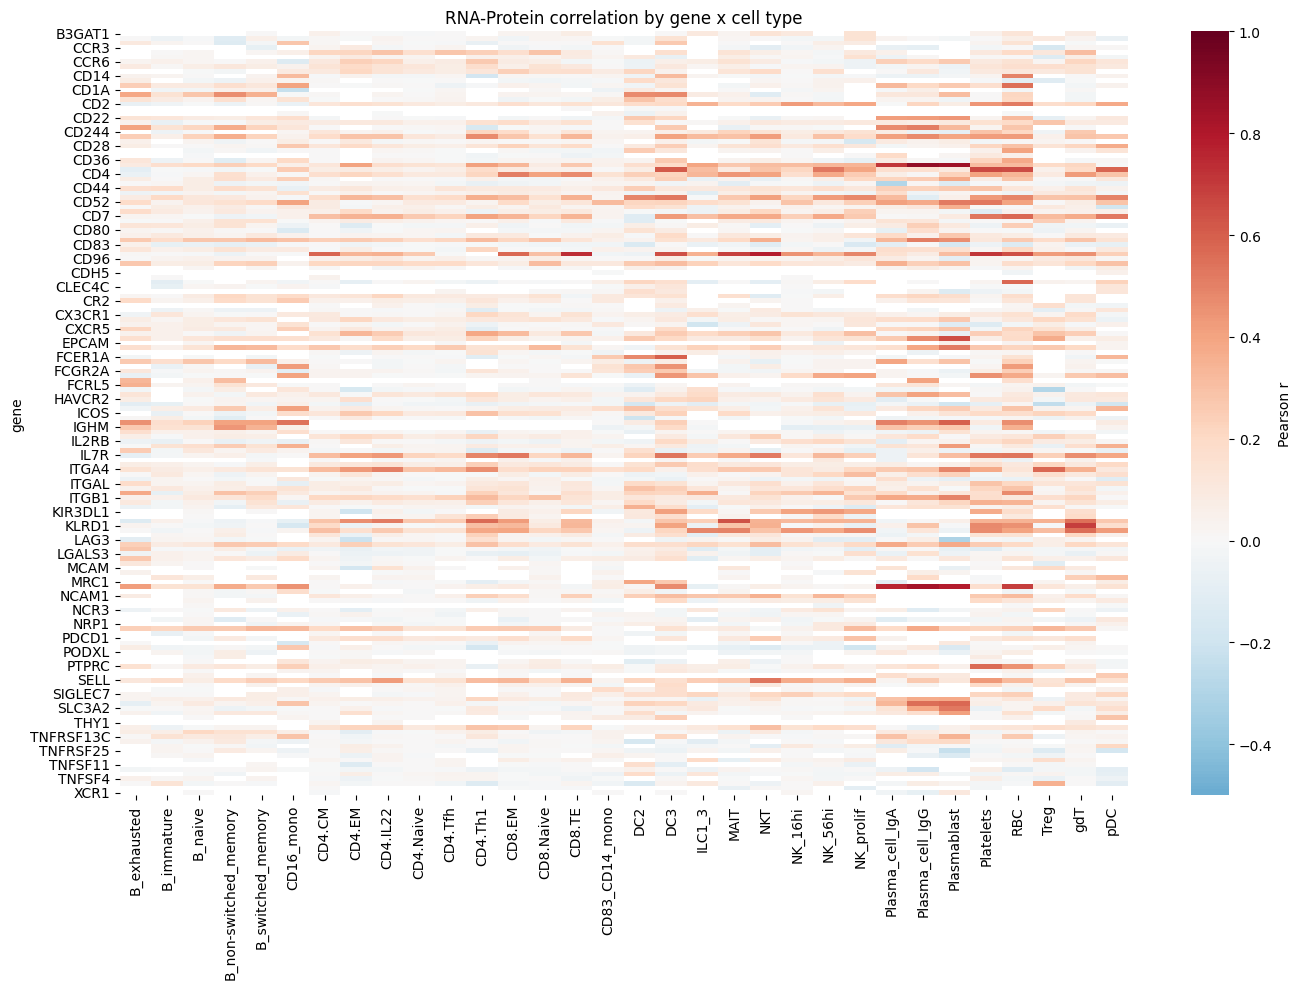

In [28]:
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(ct_corr, cmap='RdBu_r', center=0, vmin=-0.5, vmax=1.0,
            cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('RNA-Protein correlation by gene x cell type')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb02_covid_celltype_heatmap.png', dpi=150)
plt.show()

### Universal vs cell-type-specific coupling
Low variance across cell types = universal. High variance = cell-type-specific.

In [29]:
ct_variance = ct_corr.var(axis=1).sort_values(ascending=False)
ct_mean = ct_corr.mean(axis=1)

variability_df = pd.DataFrame({
    'mean_r': ct_mean, 'variance_across_celltypes': ct_variance
}).sort_values('variance_across_celltypes', ascending=False)
variability_df.to_csv(TABLES_DIR / 'nb02_covid_coupling_variability.csv')

print('--- Most cell-type-specific (high variance) ---')
display(variability_df.head(10))
print('--- Most universal (low variance) ---')
display(variability_df.tail(10))

--- Most cell-type-specific (high variance) ---


,mean_r,variance_across_celltypes
gene,,
CD8A,0.315424,0.073425
MS4A1,0.195976,0.067118
CD3D,0.184108,0.044938
KLRB1,0.230993,0.044411
IGHD,0.253277,0.044281
CD38,0.276763,0.042843
KLRD1,0.130727,0.040459
IL7R,0.257673,0.037956
KLRG1,0.227921,0.037379


--- Most universal (low variance) ---


,mean_r,variance_across_celltypes
gene,,
CD209,0.005847,0.001398
THY1,0.050214,0.001173
PVR,0.015767,0.001046
TNFSF4,0.001680,0.000998
OLR1,-0.008982,0.000804
CDH1,0.018142,0.000800
NECTIN2,-0.000833,0.000784
NCR2,-0.007302,0.000457
CEACAM8,0.016910,0.000432


## Step 6 — Patient consistency check
Is the coupling profile consistent across the 3 patients per tier? High agreement = biological signal, not noise. Columns ordered by severity tier.

In [30]:
MIN_CELLS_PER_PATIENT = 100
patients = gex_matched.obs['patient_id'].values

patient_corrs = {}
for p in np.unique(patients):
    mask = patients == p
    if mask.sum() < MIN_CELLS_PER_PATIENT:
        continue
    df = per_gene_pearson(gex_arr[mask], adt_arr[mask], matched_genes)
    patient_corrs[p] = df.set_index('gene')['pearson_r']

patient_corr_df = pd.DataFrame(patient_corrs)

# order patient columns by severity tier, so blocks of 3 sit together
patient_tier = gex_matched.obs.groupby('patient_id')[severity_col].first()
patient_order = (
    patient_tier.loc[patient_corr_df.columns]
    .astype('category').cat.set_categories(TIER_ORDER, ordered=True)
    .sort_values()
)
patient_corr_df = patient_corr_df[patient_order.index]
patient_corr_df.to_csv(TABLES_DIR / 'nb02_covid_patient_gene_corr.csv')

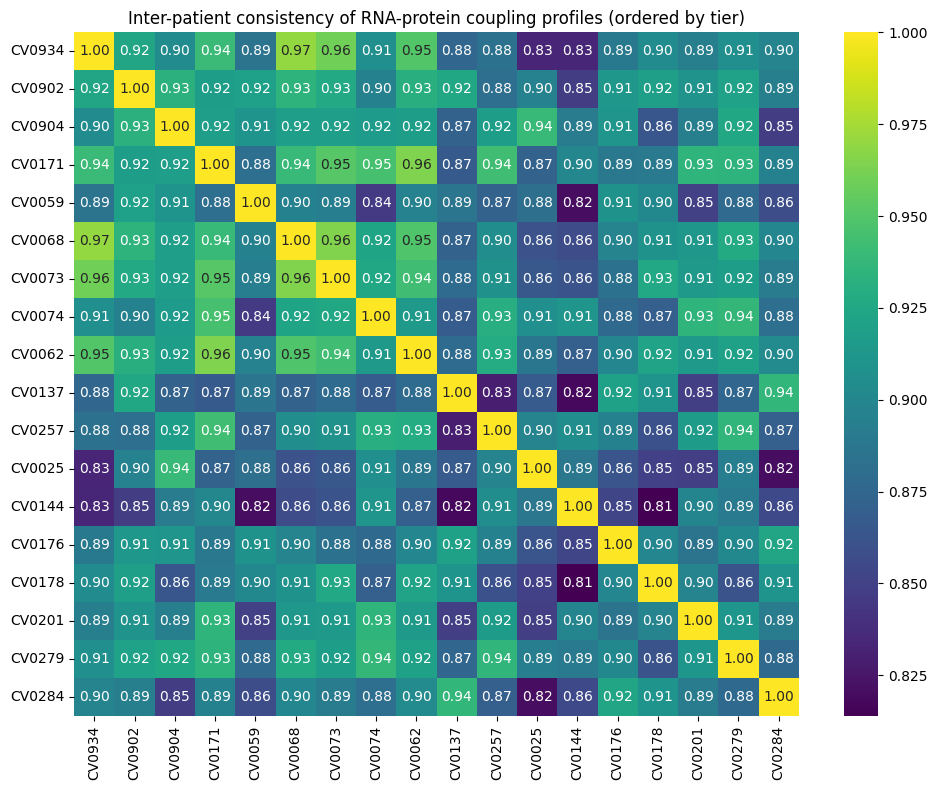

Mean pairwise patient consistency: 0.897


In [31]:
patient_consistency = patient_corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(patient_consistency, cmap='viridis', annot=True, fmt='.2f', ax=ax)
ax.set_title('Inter-patient consistency of RNA-protein coupling profiles (ordered by tier)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb02_covid_patient_consistency.png', dpi=150)
plt.show()

upper = patient_consistency.values[np.triu_indices_from(patient_consistency.values, k=1)]
print(f'Mean pairwise patient consistency: {upper.mean():.3f}')

In [32]:
qc_cols = ['n_genes_by_counts', 'total_counts', 'pct_counts_mt']
patient_qc = covid.obs.groupby('patient_id')[qc_cols].median()
patient_qc['n_cells'] = covid.obs['patient_id'].value_counts()

critical_patients = covid.obs.loc[covid.obs[severity_col] == 'Critical', 'patient_id'].unique()
print(f'Critical-tier patients: {list(critical_patients)}')
patient_qc.loc[critical_patients]

Critical-tier patients: ['CV0284', 'CV0201', 'CV0279']


,n_genes_by_counts,total_counts,pct_counts_mt,n_cells
patient_id,,,,
CV0284,1575.0,4916.0,2.416226,3995
CV0201,1446.0,4572.0,3.099394,1475
CV0279,1338.0,4030.5,3.487332,2172


In [33]:
severe_patients = covid.obs.loc[covid.obs[severity_col] == 'Severe', 'patient_id'].unique()
print(f'Severe-tier patients: {list(severe_patients)}')
patient_qc.loc[severe_patients]

Severe-tier patients: ['CV0144', 'CV0176', 'CV0178']


,n_genes_by_counts,total_counts,pct_counts_mt,n_cells
patient_id,,,,
CV0144,1468.0,5017.0,2.244626,727
CV0176,1732.0,5294.5,2.618682,2018
CV0178,1599.0,4524.5,2.424547,3894


In [34]:
ct_composition = (
    covid.obs[covid.obs['patient_id'].isin(severe_patients)]
    .groupby(['patient_id', 'full_clustering'])
    .size()
    .unstack(fill_value=0)
)
ct_composition_pct = ct_composition.div(ct_composition.sum(axis=1), axis=0) * 100
ct_composition_pct.T.sort_values(ct_composition_pct.index[0], ascending=False)

patient_id,CV0025,CV0059,CV0062,CV0068,CV0073,CV0074,CV0137,CV0144,CV0171,CV0176,CV0178,CV0201,CV0257,CV0279,CV0284,CV0902,CV0904,CV0934
full_clustering,,,,,,,,,,,,,,,,,,
ASDC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.025681,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B_exhausted,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.137552,NaN,0.049554,0.256805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B_immature,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.788171,NaN,0.198216,1.258346,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B_naive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.691884,NaN,2.824579,13.045711,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B_non-switched_memory,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.100413,NaN,0.396432,0.667694,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B_switched_memory,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.788171,NaN,0.941526,1.258346,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C1_CD16_mono,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CD14_mono,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.049554,0.359527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CD16_mono,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.099108,0.077042,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# 1. Per-patient median r for the 3 Severe patients (already computed in patient_corr_df)
patient_corr_df[severe_patients].median()

,0
CV0144,0.114489
CV0176,0.135772
CV0178,0.209761


In [36]:
# 2. DC3 reliability: how many cells actually went into that r=0.16 estimate?
for p in severe_patients:
    n = ((patients == p) & (cell_types == 'DC3')).sum()
    print(f'{p}: {n} DC3 cells')

CV0144: 1 DC3 cells
CV0176: 15 DC3 cells
CV0178: 36 DC3 cells


## Step 7 — Cell type x severity tier (core question)
Does coupling breakdown concentrate in specific cell types, or is it global across all cell types as severity increases?

In [37]:
MIN_CELLS_PER_GROUP = 100
records = []
for tier in TIER_ORDER:
    tier_mask = tiers == tier
    for ct in np.unique(cell_types):
        ct_mask = tier_mask & (cell_types == ct)
        if ct_mask.sum() < MIN_CELLS_PER_GROUP:
            continue
        df = per_gene_pearson(gex_arr[ct_mask], adt_arr[ct_mask], matched_genes)
        records.append({
            'tier': tier, 'cell_type': ct,
            'median_r': df['pearson_r'].median(), 'n_cells': ct_mask.sum(),
        })

ct_tier_df = pd.DataFrame(records)
ct_tier_df.to_csv(TABLES_DIR / 'nb02_covid_celltype_tier_median_corr.csv', index=False)
ct_tier_df.head()

,tier,cell_type,median_r,n_cells
0,Healthy,B_naive,0.036625,534
1,Healthy,B_switched_memory,0.066016,169
2,Healthy,CD4.CM,0.027891,2537
3,Healthy,CD4.IL22,0.022190,1654
4,Healthy,CD4.Naive,0.028162,1220


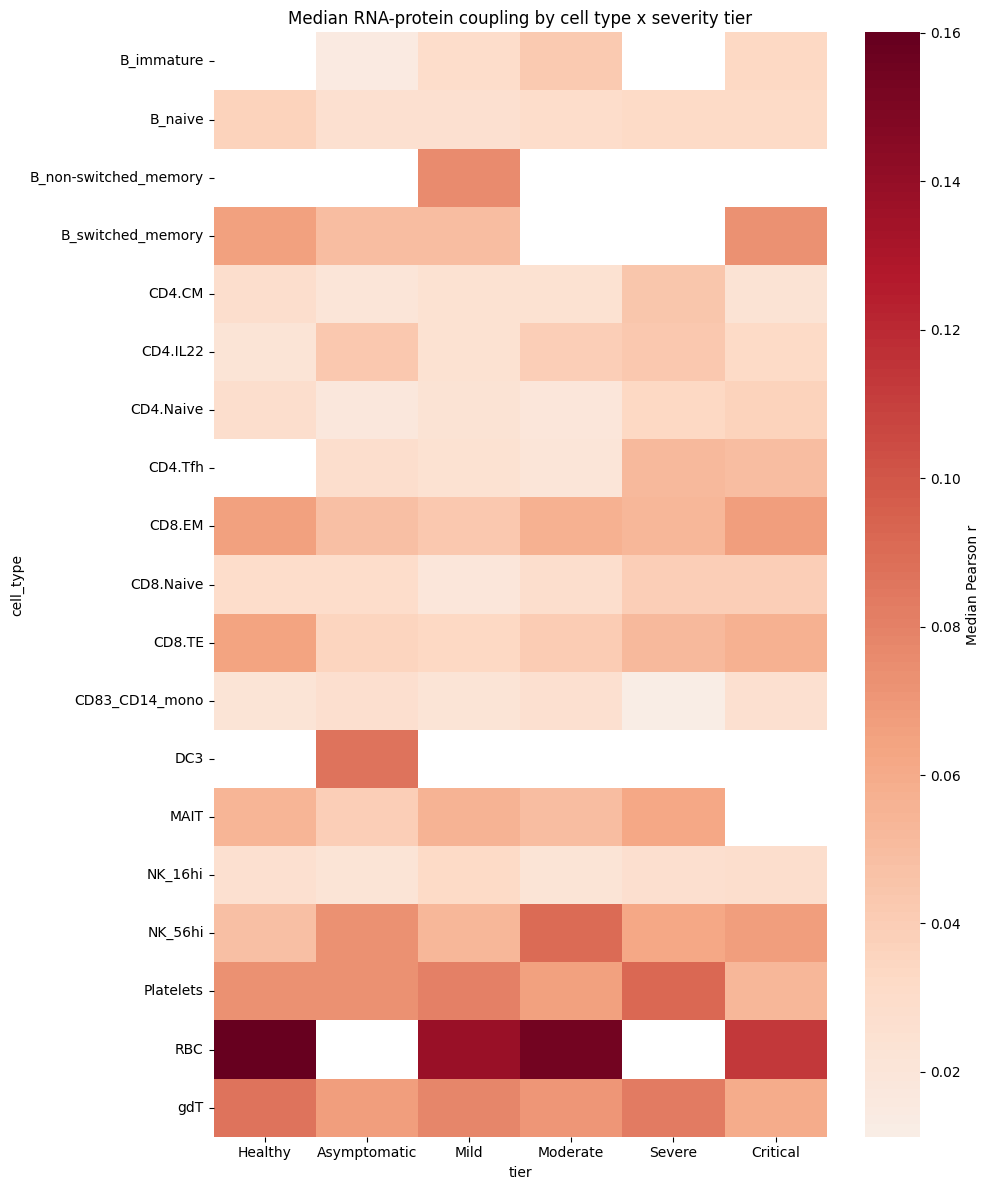

In [38]:
pivot = ct_tier_df.pivot(index='cell_type', columns='tier', values='median_r').reindex(columns=TIER_ORDER)

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(pivot, cmap='RdBu_r', center=0, cbar_kws={'label': 'Median Pearson r'}, ax=ax)
ax.set_title('Median RNA-protein coupling by cell type x severity tier')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb02_covid_celltype_tier_heatmap.png', dpi=150)
plt.show()

## Summary findings

- **ADT matching:** 165/188 matched to a GEX gene after isotype-control removal (4 dropped) and panel-specific synonyms (19 added). 2 further dropped for zero variance in GEX (`PDPN`, `KDR` — non-hematopoietic markers) -> 163 genes used in coupling analysis. Remaining 23 unmatched: CD45 isoforms, TCR clonotype/variable-region antibodies, KIR family, HLA, immunoglobulin chains, multi-gene families — not single-gene mappable.
- **Cohort correction:** `CV0198` (97.5% `B_malignant`, a comorbid clonal B-cell population) was excluded from the Critical tier and replaced with the next-largest Cambridge Critical patient (`CV0201`), keeping n=3 patients/tier. QC-based cell filtering (`n_genes_by_counts` >= 200, `pct_counts_mt` <= 5) applied upstream: 69,681 -> 62,420 cells.
- **Global coupling (all cells, all tiers):** median r = 0.133, mean r = 0.168. Top-coupled genes are canonical lineage markers (`CD8A` 0.73, `MS4A1` 0.72, `CD3D` 0.68, `IL7R` 0.62), confirming the signal reflects real biology.
- **Coupling by severity tier:** not a clean monotonic decline. Healthy 0.119 -> Asymptomatic 0.122 -> Mild 0.129 -> Moderate 0.098 -> Severe 0.182 -> Critical 0.126. The Severe-tier spike was investigated and traced to patient `CV0178` (highest cell count and highest individual median r among the 3 Severe patients — 0.210 vs 0.114/0.136) — a real patient-level effect, not a data-quality issue, but it means the global tier trend is patient-driven rather than a clean dose-response given n=3/tier. Hypothesis of coupling breakdown with severity is not supported by the global trend as-is.
- **Cell-type stratification:** genes range from strongly cell-type-specific (`CD8A`, `MS4A1`, `KLRB1`, `IGHD`, `CD3D` — high variance across cell types) to near-universal (`CD209`, `PVR`, `TNFSF4`, `CD207` — low variance, low r everywhere).
- **Patient consistency:** mean pairwise consistency = 0.897 (range 0.81–0.97), no outliers after the `CV0198` correction — coupling profiles agree well across patients within and across tiers.
- **Cell type x tier (core question):** with `min_cells=100` (raised from 50 to drop unreliable low-n estimates, e.g. a 52-cell `DC3` estimate that was driving a spurious spike), no cell type shows a clear, consistent coupling decline from Healthy to Critical. `RBC` and `CD8.EM`/`CD8.TE` show consistently higher coupling across all tiers; most cell types stay in the 0.02–0.08 range regardless of severity. No evidence yet that breakdown is concentrated in specific cell types — open question for a future session with more patients/tier.